In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pyterrier as pt
import os
from ir_measures import *
import numpy as np

if not pt.started():
    pt.init()

/tmp/ipykernel_2413/2335733035.py:8: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_2413/2335733035.py:9: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


In [2]:
hn_training_data = pd.read_csv("./monot5_sans1_hn_eval.csv")
docs = pd.read_pickle("/nfs/primary/sas_reranker/ohsumed_docs_w_t5base_sensitivity.pkl")
queries = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/queries.pkl")
qrels = pd.read_pickle("/nfs/primary/graph_adaptive_reranking/qrels.pkl")
def _sens_docs(qrels, run):
    if "sensitivity" in run.columns:
        run = run.drop(columns = ["sensitivity"])
    merged = pd.merge(run, docs, left_on = "doc_id", right_on = "docno")
    return merged.sensitivity.sum()
    
import ir_measures
sens_docs = ir_measures.define_byquery(
    _sens_docs, 
    name="sens_docs")
runs = []
run_names = []
for run in os.listdir("../../../splade_sans/sans_baselines/"):
    runs.append(pt.io.read_results(f"../../../splade_sans/sans_baselines/{run}"))
    run_names.append(run)

sans_results = pt.Experiment(
    runs[2:],
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = run_names[2:]
)

runs = []
run_names = []

for run in os.listdir("/nfs/primary/SPLADE/splade_class/runs/"):
    if "checkpoint" in run and "ipynb" not in run:
        runs.append(pt.io.read_results(f"/nfs/primary/SPLADE/splade_class/runs/{run}"))
        run_names.append(run)

distil_results = pt.Experiment(
    runs,
    queries,
    qrels,
    eval_metrics=[nDCG@10, sens_docs@10],
    names = run_names
)

splade_results = pd.read_csv("../../../splade_sans/SAS Splade Results - Sheet1.csv")
strategies = ["SPLADE SANS Strategy 1", "SPLADE SANS Strategy 2", "SPLADE SANS Strategy 3"]
splade_results = splade_results[splade_results["Approach"].isin(strategies)]
splade_results = splade_results.rename(columns = {"Approach" : "name"})

In [3]:
to_plot = pd.concat([hn_training_data, sans_results, splade_results, distil_results])
to_plot = to_plot.tail(len(to_plot) - 3)
to_plot

,name,nDCG@10,sens_docs@10,Run File
3,hn_splade_sans1_retrain-0,0.353151,0.443396,NaN
4,hn_splade_sans1_retrain-1,0.355398,0.377358,NaN
5,hn_splade_sans1_retrain-15,0.397947,0.830189,NaN
6,hn_splade_sans1_retrain-18,0.377137,0.613208,NaN
7,hn_splade_sans1_retrain-2,0.379358,0.509434,NaN
8,hn_splade_sans1_retrain-8,0.377096,0.669811,NaN
9,hn_splade_sans1_t5_base-0,0.377557,1.339623,NaN
10,hn_splade_sans1_t5_base-1,0.397048,1.009434,NaN
11,hn_splade_sans1_t5_base-10,0.422251,0.896226,NaN
12,hn_splade_sans1_t5_base-11,0.426290,0.886792,NaN


In [4]:
to_plot = to_plot[to_plot['nDCG@10'] >= 0.01]

/tmp/ipykernel_2413/983467127.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot[['color', 'marker']] = to_plot['name'].apply(lambda x: pd.Series(get_plot_style(x)))
/tmp/ipykernel_2413/983467127.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot[['color', 'marker']] = to_plot['name'].apply(lambda x: pd.Series(get_plot_style(x)))


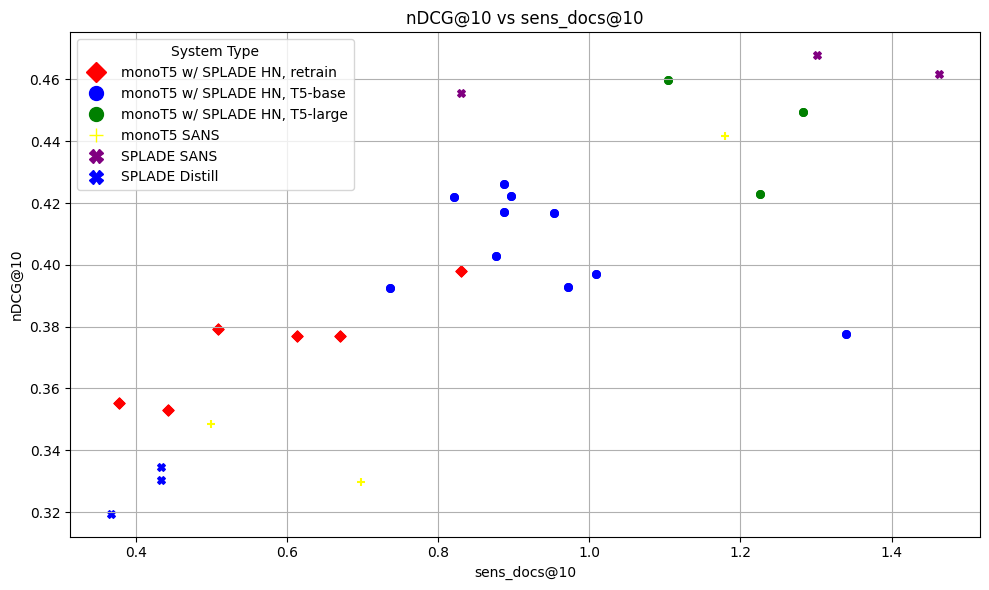

In [5]:
# Assign plotting styles
def get_plot_style(name):
    if "hn_splade_sans1_retrain" in name:
        return 'red', 'D'
    elif "hn_splade_sans1_t5_base" in name:
        return 'blue', 'o'
    elif "hn_splade_sans1_t5_large" in name:
        return 'green', 'o'
    elif name.startswith("monot5"):
        return 'yellow', '+'
    elif name.startswith("SPLADE SANS Strategy"):
        return 'purple', 'X'
    elif "retrain_checkpoint" in name:
        return 'green', 'X'
    elif "scratch_checkpoint" in name:
        return 'blue', 'X'
    else:
        return 'gray', '.'

# Add columns for color and marker
to_plot[['color', 'marker']] = to_plot['name'].apply(lambda x: pd.Series(get_plot_style(x)))

# Mapping of label codes to human-readable labels
label_mapping = {
    ('red', 'D'): 'monoT5 w/ SPLADE HN, retrain',
    ('blue', 'o'): 'monoT5 w/ SPLADE HN, T5-base',
    ('green', 'o'): 'monoT5 w/ SPLADE HN, T5-large',
    ('yellow', '+'): 'monoT5 SANS',
    ('purple', 'X'): 'SPLADE SANS',
    ('green', 'X'): 'SPLADE Distill, retrain',
    ('blue', 'X'): 'SPLADE Distill'
}

# Plot
plt.figure(figsize=(10, 6))
for _, row in to_plot.iterrows():
    plt.scatter(row['sens_docs@10'], row['nDCG@10'], color=row['color'], marker=row['marker'], s=30)

# Create custom legend with human-readable names
handles = []
labels = []
seen = set()
for color, marker in zip(to_plot['color'], to_plot['marker']):
    key = (color, marker)
    label = label_mapping.get(key, f"{color}_{marker}")
    if label not in seen:
        handles.append(plt.Line2D([0], [0], marker=marker, color='w', markerfacecolor=color,
                                  markersize=10, markeredgecolor=color))
        labels.append(label)
        seen.add(label)

plt.xlabel('sens_docs@10')
plt.ylabel('nDCG@10')
plt.title('nDCG@10 vs sens_docs@10')
plt.legend(handles, labels, title='System Type',loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig("./plots/splade_distil_no_retrain.png", dpi = 1080)

In [6]:
def find_pareto_front(df):
    # Sort by high nDCG@10 and low sens_docs@10
    sorted_df = df.sort_values(by=['nDCG@10', 'sens_docs@10'], ascending=[False, True])

    pareto_front = []
    current_best_sens = np.inf  # Track lowest sens_docs@10 seen so far

    for _, row in sorted_df.iterrows():
        if row["sens_docs@10"] <= current_best_sens:  # Pareto optimal condition
            pareto_front.append(row)
            current_best_sens = row["sens_docs@10"]

    return np.array(pareto_front)

/tmp/ipykernel_2413/3250447284.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_plot["category"] = to_plot["name"].apply(get_category)


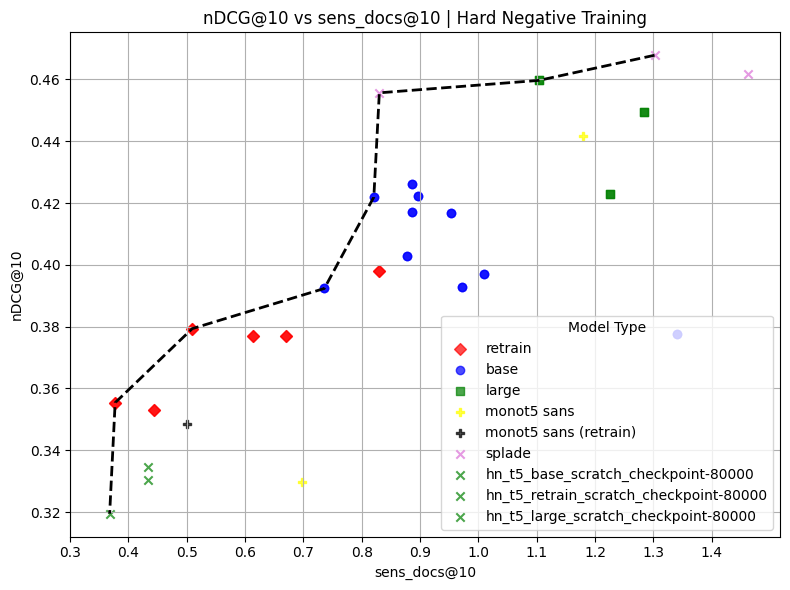

In [7]:
def get_category(name):
    if "checkpoint" in name:
        return name
    if "t5_base" in name:
        return "base"
    elif "t5_large" in name:
        return "large"
    elif "retrain" in name:
        return "retrain"
    elif "Strategy" in name:
        return "splade"
    elif "monot5_proportionate_random" in name:
        return "monot5 sans (retrain)"
    else:
        return "monot5 sans"

to_plot["category"] = to_plot["name"].apply(get_category)

# Marker and color map
markers = {"base": "o", "large": "s", "retrain": "D", "monot5 sans" : "P", "splade" : "x", "monot5 sans (retrain)" : "P"}
colors = {"base": "blue", "large": "green", "retrain": "red", "monot5 sans" : "yellow", "splade" : "orchid", "monot5 sans (retrain)" : "black"}

plt.figure(figsize=(8, 6))

pareto_front = find_pareto_front(to_plot)
plt.plot(pareto_front[:, 2], pareto_front[:, 1], color='black', linestyle='--', linewidth=2)



# Plot with different markers

for category in to_plot["category"].unique():
    subset = to_plot[to_plot["category"] == category]
    plt.scatter(
        subset["sens_docs@10"], subset["nDCG@10"],
        label=category,
        marker=markers.get(category, "x"),
        color=colors.get(category, "green"),
        alpha=0.7
    )

plt.xlabel("sens_docs@10")
plt.xticks(np.arange(0.3, 1.5, 0.1))
plt.ylabel("nDCG@10")
plt.title("nDCG@10 vs sens_docs@10 | Hard Negative Training")
plt.legend(title="Model Type")
plt.grid(True)
plt.tight_layout()
# plt.savefig("./plots/hn_training_plot.png", dpi = 1080)
plt.show()